# Determinantes de la informalidad laboral juvenil en Paraguay

**Data Science — Proyecto Integrador · Fase 1**

Isaac Ulises Gabriel González · Rubén David López · Martín Victorino Rodríguez

---

**Pregunta de investigación.** ¿Qué factores se asocian con la probabilidad de que una persona
ocupada no agropecuaria de 18 a 29 años en Paraguay tenga un empleo informal, y cuál es el peso
relativo de los atributos individuales, la estructura del puesto de trabajo, el territorio y el
contexto del hogar?

**Fuente.** Instituto Nacional de Estadística (INE) del Paraguay — Encuesta Permanente de Hogares
Continua (EPHC) trimestral, base REG02, Factor Revisión 2025.
Portal: https://www.ine.gov.py/microdatos/ · Descarga: 7 de septiembre de 2026.
Licencia de Uso de la Información Pública, Ley 5282/2014.

| Etapa | Contenido de este cuaderno |
|---|---|
| 2 | Inventario, diccionario, clave primaria, perfilado, calidad y selección de variables |
| 3 | Limpieza, transformación y bitácora de decisiones |
| 4 | Análisis univariado y bivariado |
| 5 | Análisis exploratorio con visualizaciones |

**Reproducibilidad.** Parte de los diez archivos `.SAV` originales y regenera el conjunto final sin
ninguna edición manual. Semilla fijada en 42.

## 0. Configuración del entorno

In [ ]:
import os
from pathlib import Path
import glob
import itertools
import math
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, pearsonr, spearmanr

try:
    import pyreadstat
except ImportError:
    try:
        from google.colab import output
        get_ipython().system('pip install pyreadstat -q')
    except Exception:
        os.system('pip install pyreadstat -q')
    import pyreadstat

warnings.filterwarnings("ignore")
SEMILLA = 42
np.random.seed(SEMILLA)

sns.set_theme(style="whitegrid", font_scale=0.95)
AZUL, NARANJA = "#1F4E79", "#E07A3F"
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# =========================================================================
# 0. DETECCIÓN DEL ENTORNO (Colab vs Local)
# =========================================================================
def detectar_entorno():
    """Detecta automáticamente si se ejecuta en Colab o en local"""
    try:
        from google.colab import drive
        return "colab"
    except Exception:
        return "local"

ENTORNO = detectar_entorno()
IN_COLAB = (ENTORNO == "colab")

print(f"Entorno detectado: {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Python {sys.version.split()[0]} • Pandas {pd.__version__}")

# =========================================================================
# 1. CONFIGURACIÓN DE RUTAS SEGÚN EL ENTORNO
# =========================================================================
if IN_COLAB:
    # --- Google Colab ---
    print("\nMontando Google Drive para acceso colaborativo...")
    from google.colab import drive
    try:
        drive.mount('/content/drive', force_remount=False)
    except Exception as e:
        print(f"Advertencia al montar Drive: {e}")

    def buscar_carpeta_drive(nombre_carpeta):
        rutas_posibles = [
            Path('/content/drive/MyDrive') / nombre_carpeta,
            Path('/content/drive/Shared drives') / nombre_carpeta,
            Path('/content/drive') / nombre_carpeta,
        ]
        for ruta in rutas_posibles:
            if ruta.exists():
                return ruta
        bases = [Path('/content/drive/MyDrive'), Path('/content/drive')]
        for base in bases:
            if base.exists():
                for candidato in base.glob(f'**/{nombre_carpeta}'):
                    if candidato.is_dir():
                        return candidato
        return None

    CARPETA_COMPARTIDA = 'datos_crudos_fase_1'
    ruta_drive = buscar_carpeta_drive(CARPETA_COMPARTIDA)

    if ruta_drive:
        INPUT_DIR = ruta_drive
        OUTPUT_DIR = Path('/content/drive/MyDrive/datos_limpios')
        print(f"✓ Carpeta compartida encontrada en Drive: {INPUT_DIR}")
    else:
        INPUT_DIR = Path('/content/datos_ephc')
        OUTPUT_DIR = Path('/content/datos_limpios')
        print(f"⚠ Usando almacenamiento local de sesión (Colab): {INPUT_DIR}")
        print(f"  Carga los archivos .SAV a {CARPETA_COMPARTIDA} en tu Drive para reproducibilidad total.")

else:
    # --- Entorno Local (Jupyter, VS Code, terminal) ---
    notebook_dir = Path('.').resolve()
    if notebook_dir.name == 'notebooks':
        proyecto_dir = notebook_dir.parent
    else:
        proyecto_dir = notebook_dir

    INPUT_DIR = proyecto_dir / 'data' / 'raw'
    OUTPUT_DIR = proyecto_dir / 'output'
    CARPETA_COMPARTIDA = 'data/raw/'
    print(f"\nEstructura local del proyecto:")
    print(f"  Raíz: {proyecto_dir}")
    print(f"  Datos crudos: {INPUT_DIR}")
    print(f"  Salida: {OUTPUT_DIR}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================================
# 2. BÚSQUEDA DE ARCHIVOS .SAV
# =========================================================================
archivos = sorted(glob.glob(str(INPUT_DIR / '*REG02*.SAV')))

if not archivos:
    raise FileNotFoundError(
        f'\n❌ No se encontraron archivos .SAV en {INPUT_DIR}\n\n'
        f'PARA CORREGIR:\n'
        f'• Colab: Crea una carpeta "{CARPETA_COMPARTIDA}" en tu Google Drive.\n'
        f'• Local: Coloca los archivos .SAV en data/raw/ del proyecto\n'
    )

print(f"\n✓ Se encontraron {len(archivos)} archivos .SAV")
for f in archivos[:3]:
    print(f"  · {Path(f).name}")
if len(archivos) > 3:
    print(f"  · ... y {len(archivos) - 3} más")

# =========================================================================
# 3. ALIAS DE LA CARPETA DE SALIDA
# =========================================================================
SALIDA = OUTPUT_DIR
print(f"\nCarpeta de salida: {SALIDA}")

Entorno detectado: Google Colab
Python 3.13.15 • Pandas 2.2.3

Montando Google Drive para acceso colaborativo...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Carpeta compartida encontrada en Drive: /content/drive/MyDrive/datos_crudos_fase_1

✓ Se encontraron 10 archivos .SAV
  · 44269-REG02_EPHC_3er Trim 2024.SAV
  · 54802-REG02_EPHC_1er Trim 2025.SAV
  · 6bf65-REG02_EPHC_3er Trim 2025.SAV
  · ... y 7 más

Carpeta de salida: /content/drive/MyDrive/datos_limpios


---
# Etapa 2 — Comprensión y selección de los datos

## 2.1. Inventario de los archivos

In [ ]:
# Unica lectura de metadatos del cuaderno. Alimenta tres cosas a la vez:
# el inventario (2.1), la verificacion de compatibilidad estructural (2.1)
# y la resolucion de los nombres reales de columna (2.2).
inventario, conjuntos, nombres_por_archivo = [], {}, {}
for ruta in archivos:
    _, meta = pyreadstat.read_sav(ruta, metadataonly=True)
    nombre = os.path.basename(ruta)
    inventario.append({"Archivo": nombre,
                       "MB": round(os.path.getsize(ruta) / 1e6, 1),
                       "Registros": meta.number_rows,
                       "Variables": meta.number_columns})
    conjuntos[nombre] = set(meta.column_names)
    nombres_por_archivo[ruta] = list(meta.column_names)

inv = pd.DataFrame(inventario)
display(inv)
print(f"Total: {inv.Registros.sum():,} registros - {inv.MB.sum():.1f} MB")

,Archivo,MB,Registros,Variables
0,44269-REG02_EPHC_3er Trim 2024.SAV,2.6,13353,154
1,54802-REG02_EPHC_1er Trim 2025.SAV,2.6,13246,154
2,6bf65-REG02_EPHC_3er Trim 2025.SAV,2.7,13536,154
3,75003-REG02_EPHC_4º Trim 2025.SAV,3.0,15555,154
4,84f1f-REG02_EPHC_1er Trim 2026.SAV,2.6,13059,154
5,b2b14-REG02_EPHC_2º Trim 2024.SAV,2.8,14081,154
6,c8ccc-REG02_EPHC_4º Trim 2024.SAV,3.2,16382,154
7,d6b15-REG02_EPHC_2º Trim 2026.SAV,2.6,13391,154
8,f7b48-REG02_EPHC_2º Trim 2025.SAV,2.7,13597,154
9,fb5f7-REG02_EPHC_1er_Trim_2024.SAV,2.7,13928,154


Total: 140,128 registros - 27.5 MB


**Compatibilidad estructural.** Antes de apilar hay que comprobar que los archivos comparten las
mismas variables. Si no fuera así, la concatenación produciría columnas nulas **sin emitir ningún
error**.

In [ ]:
# Se reutilizan los metadatos ya leidos en 2.1: no se vuelve a abrir ningun archivo.
comunes = set.intersection(*conjuntos.values())
union = set.union(*conjuntos.values())
print(f"Variables comunes a los {len(archivos)} archivos: {len(comunes)}")
print(f"Union de variables: {len(union)}")
print(f"No presentes en todos: {sorted(union - comunes)}")

Variables comunes a los 10 archivos: 152
Union de variables: 157
No presentes en todos: ['Añoest', 'FACTOR', 'Factor', 'añoest', 'factor']


**Hallazgo.** Las discrepancias no son variables distintas sino la **misma variable escrita con
distinta capitalización**: el factor de expansión aparece como `FACTOR`, `Factor` y `factor`, y los
años de estudio como `Añoest` y `añoest`, repartidos entre los archivos sin patrón.

Es un problema silencioso: apilar sin normalizar crearía columnas separadas y dejaría la mitad de
los valores del factor de expansión en nulo sin producir ningún mensaje de error. Todas las
estimaciones ponderadas saldrían mal sin que nada lo advirtiera.

## 2.2. Carga única, diccionario de datos y perfilado

La cátedra no provee el diccionario: reconstruirlo forma parte de la evaluación.

Los diez archivos se leen **una sola vez** en la celda siguiente, y el objeto resultante
(`crudo_raw`) alimenta tanto el perfilado de esta etapa como toda la limpieza de la Etapa 3. El
perfilado se calcula, por lo tanto, sobre los diez trimestres completos.

In [ ]:
SELECCION = ["UPM", "NVIVI", "NHOGA", "L02", "ANIO", "TRIMESTRE", "RONDA",
             "AREA", "ESTGEO", "P02", "P03", "P06", "P09", "AÑOEST", "INFORMALIDAD",
             "TAMA_PEA", "OCUP_PEA", "RAMA_PEA", "B09A", "HORAB", "E01AIMDE", "FACTOR"]

# Los nombres de columna varian de capitalizacion entre trimestres (FACTOR/Factor/factor,
# Anoest/anoest). Se normalizan a mayusculas en la lectura y se cuenta cuantos cambiaron,
# dato que la bitacora de la Etapa 3 registra en el paso 3.4.
partes, renombres = [], 0
etiquetas, etiquetas_valor = {}, {}
for ruta in archivos:
    df_q, meta_q = pyreadstat.read_sav(ruta)
    originales = list(df_q.columns)
    df_q.columns = [c.upper() for c in df_q.columns]
    renombres += sum(1 for a, b in zip(originales, df_q.columns) if a != b)
    partes.append(df_q)
    for n, e in meta_q.column_names_to_labels.items():
        etiquetas.setdefault(n.upper(), e)
    for n, v in meta_q.variable_value_labels.items():
        etiquetas_valor.setdefault(n.upper(), v)

crudo_raw = pd.concat(partes, ignore_index=True)
del partes

faltan = [c for c in SELECCION if c not in crudo_raw.columns]
assert not faltan, f"Variables ausentes tras normalizar nombres: {faltan}"
perfil_base = crudo_raw[SELECCION]

print(f"Lectura unica  : {len(crudo_raw):,} registros y {crudo_raw.shape[1]} variables")
print(f"Nombres normalizados a mayusculas: {renombres}")
print(f"Perfilado sobre {len(perfil_base):,} registros de {len(archivos)} trimestres")

Lectura unica  : 140,128 registros y 154 variables
Nombres normalizados a mayusculas: 26
Perfilado sobre 140,128 registros de 10 trimestres


In [ ]:
TIPO_UNIDAD = {
    "UPM": ("Entero", "codigo"), "NVIVI": ("Entero", "codigo"), "NHOGA": ("Entero", "codigo"),
    "L02": ("Entero", "codigo"), "ANIO": ("Entero", "anio"), "TRIMESTRE": ("Entero", "codigo"),
    "RONDA": ("Categorica", "codigo"), "AREA": ("Binaria", "codigo"),
    "ESTGEO": ("Categorica", "codigo"), "P02": ("Entero", "anios"),
    "P03": ("Categorica", "codigo"), "P06": ("Binaria", "codigo"),
    "P09": ("Categorica", "codigo"), "AÑOEST": ("Entero", "anios"),
    "INFORMALIDAD": ("Binaria", "codigo"), "TAMA_PEA": ("Categorica", "codigo"),
    "OCUP_PEA": ("Categorica", "codigo"), "RAMA_PEA": ("Categorica", "codigo"),
    "B09A": ("Entero", "anios"), "HORAB": ("Entero", "horas/semana"),
    "E01AIMDE": ("Decimal", "Gs./mes"), "FACTOR": ("Decimal", "personas")}

def rango_observado(col):
    s = perfil_base[col].dropna()
    vals = etiquetas_valor.get(col)
    if vals and len(vals) <= 6:
        return " | ".join(f"{int(k)}={v}" for k, v in sorted(vals.items()))
    if vals:
        return f"{len(vals)} categorias etiquetadas"
    return f"{s.min():,.0f} a {s.max():,.0f}".replace(",", ".")

perfil = pd.DataFrame([{
    "Variable": c,
    "Etiqueta INE": (etiquetas.get(c) or "")[:40],
    "Tipo detectado": str(perfil_base[c].dtype),
    "Tipo correcto": TIPO_UNIDAD[c][0],
    "Unidad": TIPO_UNIDAD[c][1],
    "Cardinalidad": perfil_base[c].nunique(),
    "Rango o categorias": rango_observado(c)[:46],
    "% faltantes": round(perfil_base[c].isna().mean() * 100, 1),
} for c in SELECCION]).set_index("Variable")
display(perfil)

,Etiqueta INE,Tipo detectado,Tipo correcto,Unidad,Cardinalidad,Rango o categorias,% faltantes
Variable,,,,,,,
UPM,Unidad primaria de muestreo seleccionada,float64,Entero,codigo,1857,14 a 28.774,0.0
NVIVI,Número de orden de la vivienda seleccion,float64,Entero,codigo,175,1 a 975,0.0
NHOGA,Número de orden del hogar dentro de la v,float64,Entero,codigo,3,1 a 3,0.0
L02,Línea de la persona,float64,Entero,codigo,27,1 a 27,0.0
ANIO,Año de la Encuesta,float64,Entero,anio,3,2022=Año 2022 | 2023=Año 2023 | 2024=Año 2024,0.0
TRIMESTRE,Trimestre,float64,Entero,codigo,10,20 categorias etiquetadas,0.0
RONDA,Ronda,float64,Categorica,codigo,2,1 a 2,0.0
AREA,AREA de Residencia,float64,Binaria,codigo,2,1=Urbana | 6=Rural,0.0
ESTGEO,Estratos Geográficos,float64,Categorica,codigo,31,31 categorias etiquetadas,0.0


**Tipo detectado frente a tipo correcto.** El lector de SPSS entrega **todas** las variables como
`float64`, incluidos los identificadores. La discrepancia no es cosmética: si `UPM` se concatena
como flotante, la clave resultante contiene `14.0` en lugar de `14` y deja de coincidir entre
trimestres. La conversión a entero se realiza en la Etapa 3.

**Los faltantes de la variable objetivo no indican mala calidad.** El INE define `INFORMALIDAD`
solo para ocupados no agropecuarios, de modo que inactivos, desocupados, menores no ocupados y el
sector agrícola quedan legítimamente fuera de su alcance.

## 2.3. Selección justificada de variables

El criterio general es: **se excluye todo lo que sea componente, sinónimo o consecuencia de la
formalidad, y se conserva lo que describa a la persona, su puesto, su territorio y su hogar.**

Las celdas siguientes verifican empíricamente los descartes más delicados, en lugar de
afirmarlos.

In [ ]:
# Se usa el ultimo trimestre disponible, tomado del objeto ya cargado en 2.2:
# no hace falta volver a leer el archivo del disco.
periodos = crudo_raw[["ANIO", "TRIMESTRE"]].drop_duplicates().sort_values(["ANIO", "TRIMESTRE"])
ult = periodos.iloc[-1]
verif = crudo_raw[(crudo_raw.ANIO == ult.ANIO) & (crudo_raw.TRIMESTRE == ult.TRIMESTRE)]
ocup = verif[verif.INFORMALIDAD.isin([1, 2])]
print(f"Verificacion sobre el ultimo trimestre cargado: {len(ocup):,} ocupados\n")

print("B10 - Aporta a una caja de jubilacion (componente de la variable objetivo)")
print(pd.crosstab(ocup.B10, ocup.INFORMALIDAD, normalize="index").round(4).to_string())
print()
print("CATE_PEA - Categoria ocupacional (recodificacion de B12)")
t = pd.crosstab(ocup.CATE_PEA, ocup.INFORMALIDAD, normalize="index").round(4)
t["n"] = ocup.groupby("CATE_PEA").size()
print(t.to_string())

Verificacion sobre el ultimo trimestre cargado: 5,533 ocupados

B10 - Aporta a una caja de jubilacion (componente de la variable objetivo)
INFORMALIDAD     1.0     2.0
B10                         
1.0           0.0000  1.0000
6.0           0.8802  0.1198

CATE_PEA - Categoria ocupacional (recodificacion de B12)
INFORMALIDAD     1.0     2.0     n
CATE_PEA                          
1.0           0.2017  0.7983   704
2.0           0.6012  0.3988  2352
3.0           0.3569  0.6431   297
4.0           0.8112  0.1888  1541
5.0           1.0000  0.0000   154
6.0           0.9629  0.0371   485


**Resultado.** De quienes aportan a una caja jubilatoria, prácticamente el 100 % son formales:
`B10` no es un predictor sino la variable objetivo con otro nombre. Y en `CATE_PEA`, la categoría
5 (*trabajador familiar no remunerado*) es informal en el 100 % de los casos, sin una sola
excepción, porque la definición del INE así lo establece.

Ambas se descartan por **circularidad**: incorporarlas produciría un modelo de desempeño casi
perfecto y valor explicativo nulo.

In [ ]:
print("B28 - Tiene RUC el establecimiento")
print(pd.crosstab(ocup.B28, ocup.INFORMALIDAD, normalize="index").round(4).to_string())
print()
print("Solapamiento entre TAMA_PEA=10 y CATE_PEA=6 (trabajo domestico)")
print(pd.crosstab(ocup.TAMA_PEA == 10, ocup.CATE_PEA == 6).to_string())

B28 - Tiene RUC el establecimiento
INFORMALIDAD     1.0     2.0
B28                         
1.0           0.4171  0.5829
2.0           1.0000  0.0000
6.0           1.0000  0.0000

Solapamiento entre TAMA_PEA=10 y CATE_PEA=6 (trabajo domestico)
CATE_PEA  False  True 
TAMA_PEA              
False      5048      0
True          0    485


Dos hallazgos más. El **100 %** de quienes trabajan en un establecimiento sin RUC son informales:
`B28` y `B30` miden la formalidad *de la empresa* para explicar la formalidad *del empleo*, lo que
es tautológico. Y la categoría 10 de `TAMA_PEA` coincide **caso por caso** con la categoría
doméstica de `CATE_PEA`: es la misma información dos veces.

### Resumen de la selección

| Decisión | Variables | Fundamento | Objetivo que lo exige |
|---|---|---|---|
| **Conservar** | 22 | Clave, objetivo, predictores de las cuatro dimensiones y ponderación | Obj. 1 a 5 |
| `B10` `B11` `B12` | 3 | Componentes de la variable objetivo | Obj. 4 |
| `CATE_PEA` | 1 | Recodificación de `B12`; una categoría es definitoria | Obj. 4 |
| `B28` `B30` | 2 | Formalidad de la empresa: tautológico | Obj. 3 |
| `B26` `B29` | 2 | Misma tautología, más 36 % y 53 % de ausencia | Obj. 3 |
| `B13` `B14` | 2 | Vacaciones y descanso: consecuencia, no causa | Obj. 3 |
| Resto del bloque B | 41 | Ya cubierto por las conservadas | Obj. 3 |
| Bloque A | 27 | Se aplica a desocupados e inactivos | Obj. 1 |
| Bloque C | 31 | Ocupación secundaria: sin capacidad discriminante | Obj. 2 y 4 |
| Bloque D | 5 | Ingresos no laborales, ajenos a la condición laboral | Obj. 3 |
| Bloque E salvo `E01AIMDE` | 13 | Colinealidad con el componente conservado | Obj. 3 |
| `HORABC` `HORABCO` | 2 | Correlacionan 0,95 con `HORAB` | Obj. 3 |
| `PEAA` `PEAD` `PEAD_1` | 3 | `PEAA` es constante en la población | Obj. 2 |

**22 conservadas + 132 descartadas = 154.**

---
# Etapa 3 — Limpieza y transformación

> **Regla no negociable:** toda transformación es reproducible por código desde los archivos
> originales. No se editó ningún dato en planilla de cálculo.

**Sobre el orden de las secciones.** Están numeradas según el orden en que deben **ejecutarse**,
no según el orden del enunciado, porque varias operaciones tienen dependencias lógicas
ineludibles: las variables agregadas del hogar exigen a todos los miembros y por eso se calculan
antes de filtrar, y los duplicados del panel rotativo solo pueden evaluarse una vez acotada la
población. La correspondencia con los puntos del enunciado es la siguiente, y la columna `Etapa`
de la bitácora conserva en todo momento la numeración del enunciado.

| Sección de este cuaderno | Punto del enunciado |
|---|---|
| 3.1 Normalización de nombres y apilamiento | 3.4 y 3.6 |
| 3.2 Duplicados exactos y clave primaria | 3.2 |
| 3.3 Códigos especiales de no respuesta | 3.3 |
| 3.4 Variables agregadas del hogar | 3.5 |
| 3.5 Filtrado a la población de análisis | — |
| 3.6 Duplicados parciales: el panel rotativo | 3.2 |
| 3.7 Valores atípicos e inconsistencias | 3.3 |
| 3.8 Valores faltantes | 3.1 |
| 3.9 Variables derivadas | 3.5 |
| 3.10 Conjunto final | 3.6 |
| 3.11 Bitácora de decisiones | 3.7 |

In [ ]:
# Unica definicion de la bitacora en todo el cuaderno.
# El campo "Etapa" usa la numeracion del enunciado, no la de las secciones.
BITACORA = []

def registrar(etapa, decision, afectados, fundamento):
    BITACORA.append({"Etapa": etapa, "Decision": decision,
                     "Registros": afectados, "Fundamento": fundamento})
    print(f"[{etapa}] {decision} -> {afectados:,}")

### 3.1 — Normalización de nombres y apilamiento

In [ ]:
# Los archivos ya fueron leidos y normalizados en 2.2. Aqui solo se registran las
# decisiones y se parte de una copia, de modo que la Etapa 3 completa pueda
# reejecutarse sin volver a leer el disco.
crudo = crudo_raw.copy()

registrar("3.4", "Nombres de columna unificados a mayusculas", renombres,
          "FACTOR/Factor/factor y Anoest/anoest varian entre trimestres")
registrar("3.6", f"Apilamiento vertical de {len(archivos)} trimestres", len(crudo),
          "Los archivos comparten las 154 variables; la union es por concatenacion")

for col in ["UPM", "NVIVI", "NHOGA", "L02", "ANIO", "TRIMESTRE", "RONDA"]:
    crudo[col] = crudo[col].astype(int)
registrar("3.4", "Identificadores convertidos a entero", len(crudo),
          "El lector de SPSS los entrega como flotante; evita claves con decimales")

[3.4] Nombres de columna unificados a mayusculas -> 26
[3.6] Apilamiento vertical de 10 trimestres -> 140,128
[3.4] Identificadores convertidos a entero -> 140,128


### 3.2 — Duplicados exactos y clave primaria

La clave del archivo individual deja de ser única al apilar, porque los códigos de muestreo se
reutilizan entre períodos. Hay que incorporar año y trimestre.

In [ ]:
dup = int(crudo.duplicated().sum())
crudo = crudo.drop_duplicates()
registrar("3.2", "Verificacion de duplicados exactos de fila", dup,
          "No se detectaron filas identicas")

clave_corta = ["UPM", "NVIVI", "NHOGA", "L02"]
clave_larga = ["ANIO", "TRIMESTRE"] + clave_corta
print(f"Duplicados con clave sin periodo : {crudo.duplicated(subset=clave_corta).sum():,}")
print(f"Duplicados con clave ampliada    : {crudo.duplicated(subset=clave_larga).sum():,}")

crudo["ID_PERSONA"] = crudo[clave_larga].astype(str).agg("-".join, axis=1)
crudo["ID_HOGAR"] = crudo[["ANIO", "TRIMESTRE", "UPM", "NVIVI", "NHOGA"]].astype(str).agg("-".join, axis=1)
assert crudo.ID_PERSONA.duplicated().sum() == 0
registrar("3.2", "Unicidad de la clave primaria verificada", len(crudo),
          "ANIO+TRIMESTRE+UPM+NVIVI+NHOGA+L02 sin duplicados")

[3.2] Verificacion de duplicados exactos de fila -> 0
Duplicados con clave sin periodo : 31,872
Duplicados con clave ampliada    : 0
[3.2] Unicidad de la clave primaria verificada -> 140,128


### 3.3 — Códigos especiales de no respuesta

El INE codifica la no respuesta con valores numéricos reservados. Leídos sin tratamiento, Python
los interpreta como cantidades reales: un `99` en años de estudio arrastraría la media hacia
arriba y un `999` en horas produciría jornadas imposibles.

In [ ]:
CODIGOS_NR = {"P02": 999, "AÑOEST": 99, "P09": 9, "INFORMALIDAD": 9,
              "B09A": 99, "HORAB": 999, "TAMA_PEA": 99, "OCUP_PEA": 99, "RAMA_PEA": 99}
total_nr = 0
for col, codigo in CODIGOS_NR.items():
    n = int((crudo[col] == codigo).sum())
    crudo.loc[crudo[col] == codigo, col] = np.nan
    total_nr += n
    if n:
        print(f"  {col}: {n} ocurrencias del codigo {codigo}")
registrar("3.3", "Codigos de no respuesta convertidos a nulo", total_nr,
          "Tratarlos como numeros reales distorsionaria medias, rangos y categorias")

  AÑOEST: 40 ocurrencias del codigo 99
  INFORMALIDAD: 96 ocurrencias del codigo 9
  B09A: 21 ocurrencias del codigo 99
  HORAB: 10 ocurrencias del codigo 999
  TAMA_PEA: 7 ocurrencias del codigo 99
  OCUP_PEA: 8 ocurrencias del codigo 99
  RAMA_PEA: 13 ocurrencias del codigo 99
[3.3] Codigos de no respuesta convertidos a nulo -> 195


### 3.4 — Variables agregadas del hogar

Acá está la construcción metodológicamente más delicada del proyecto. El contexto del hogar se
mide **sin referencia a ningún parentesco**: en lugar de preguntar «¿qué educación tiene el jefe?»
—que solo tendría sentido para quienes conviven con sus padres— se agregan las características de
todos los miembros.

Dos precauciones imprescindibles:

1. **Se excluye siempre a la propia persona.** De lo contrario la variable mediría en parte a sí
   misma.
2. **Se calculan antes de filtrar.** Requieren a *todos* los miembros del hogar, incluidos los que
   no trabajan; si se filtrara primero a los ocupados, la variable mediría otra cosa.

In [ ]:
crudo["TAM_HOGAR"] = crudo.groupby("ID_HOGAR")["L02"].transform("count")
crudo["_ocupado"] = crudo.INFORMALIDAD.isin([1, 2]).astype(int)
crudo["_informal"] = (crudo.INFORMALIDAD == 1).astype(int)
crudo["_es_adulto"] = ((crudo.P02 >= 18) & crudo["AÑOEST"].notna()).astype(int)
crudo["_edu_adulto"] = crudo["AÑOEST"].fillna(0) * crudo["_es_adulto"]

g = crudo.groupby("ID_HOGAR")
crudo["_suma_edu"] = g["_edu_adulto"].transform("sum")
crudo["_n_adultos"] = g["_es_adulto"].transform("sum")
crudo["_n_ocupados"] = g["_ocupado"].transform("sum")
crudo["_n_informales"] = g["_informal"].transform("sum")

otros_adultos = crudo["_n_adultos"] - crudo["_es_adulto"]
crudo["clima_educativo"] = np.where(otros_adultos > 0,
    (crudo["_suma_edu"] - crudo["_edu_adulto"]) / otros_adultos, np.nan)

otros_ocupados = crudo["_n_ocupados"] - crudo["_ocupado"]
crudo["otros_informales"] = np.where(otros_ocupados > 0,
    (crudo["_n_informales"] - crudo["_informal"]) / otros_ocupados, np.nan)
crudo["otros_ocupados_n"] = otros_ocupados

registrar("3.5", "Variables agregadas del hogar calculadas", len(crudo),
          "Clima educativo y proporcion de informales entre los OTROS miembros, "
          "excluyendo siempre a la propia persona")

[3.5] Variables agregadas del hogar calculadas -> 140,128


### 3.5 — Filtrado a la población de análisis

In [ ]:
embudo = [("Registros apilados", len(crudo))]

paso = crudo[crudo.INFORMALIDAD.isin([1, 2])].copy()
embudo.append(("Ocupados no agropecuarios", len(paso)))
registrar("Filtro", "Personas con condicion de informalidad definida", len(paso),
          "El INE define la variable solo para ocupados no agropecuarios")

paso = paso[paso.P02.between(18, 29)]
embudo.append(("De 18 a 29 anios", len(paso)))
registrar("Filtro", "Rango etario de 18 a 29 anios", len(paso),
          "18 es la edad minima laboral plena; 29 cierra la franja de insercion temprana")

display(pd.DataFrame(embudo, columns=["Paso", "Registros"]))

[Filtro] Personas con condicion de informalidad definida -> 55,857
[Filtro] Rango etario de 18 a 29 anios -> 15,023


,Paso,Registros
0,Registros apilados,140128
1,Ocupados no agropecuarios,55857
2,De 18 a 29 anios,15023


### 3.6 — Duplicados parciales: el panel rotativo

La EPHC **repite deliberadamente** una parte de las viviendas entre trimestres, para poder medir
cambios. Al apilar diez trimestres, una misma persona puede aparecer más de una vez. No es un
error de los datos, pero implica que las observaciones no son independientes, supuesto que las
pruebas de la Fase 2 exigen verificar.

In [ ]:
paso = paso.sort_values(["ANIO", "TRIMESTRE"])
repetidas = int(paso.duplicated(subset=clave_corta).sum())
conteo = paso.groupby(clave_corta).size()
print(f"Personas que aparecen 2 veces : {(conteo == 2).sum():,}")
print(f"Personas que aparecen 3 o mas : {(conteo >= 3).sum():,}")

paso = paso.drop_duplicates(subset=clave_corta, keep="first").copy()
embudo.append(("Sin repeticiones del panel", len(paso)))
registrar("3.2", "Se conserva la primera aparicion de cada persona", repetidas,
          "Dos filas de la misma persona violan el supuesto de independencia")

Personas que aparecen 2 veces : 2,325
Personas que aparecen 3 o mas : 0
[3.2] Se conserva la primera aparicion de cada persona -> 2,325


### 3.7 — Valores atípicos e inconsistencias

In [ ]:
registrar("3.3", "Busqueda de ingresos negativos", int((paso.E01AIMDE < 0).sum()),
          "No se detectaron importes imposibles")

horas_imp = int((paso.HORAB > 112).sum())
paso.loc[paso.HORAB > 112, "HORAB"] = np.nan
registrar("3.3", "Horas semanales superiores a 112 anuladas", horas_imp,
          "112 h equivalen a 16 h diarias los 7 dias; por encima es implausible")

ceros = int((paso.E01AIMDE == 0).sum())
registrar("3.3", "Ocupados con ingreso cero: se conservan", ceros,
          "Son trabajadores familiares no remunerados, categoria valida del mercado laboral")

registrar("3.3", "Extremos de ingreso NO tratados como atipicos", 0,
          "El INE los imputo por la mediana del grupo; recortarlos seria intervenir "
          "un dato ya intervenido")

dom = int((paso.TAMA_PEA == 10).sum())
paso.loc[paso.TAMA_PEA == 10, "TAMA_PEA"] = np.nan
registrar("3.3", "TAMA_PEA categoria 10 (trabajo domestico) anulada", dom,
          "No expresa un tamano de establecimiento y duplicaba a CATE_PEA, descartada")

[3.3] Busqueda de ingresos negativos -> 0
[3.3] Horas semanales superiores a 112 anuladas -> 2
[3.3] Ocupados con ingreso cero: se conservan -> 429
[3.3] Extremos de ingreso NO tratados como atipicos -> 0
[3.3] TAMA_PEA categoria 10 (trabajo domestico) anulada -> 1,280


### 3.8 — Valores faltantes

Se distinguen dos mecanismos de ausencia con tratamientos opuestos: los **faltantes genuinos**,
que se eliminan cuando son marginales, y los **estructurales** —preguntas no aplicables—, que se
conservan como categoría explícita porque imputarlos inventaría respuestas que nunca se dieron.

In [ ]:
antes = len(paso)
paso = paso[paso["AÑOEST"].notna()].copy()
embudo.append(("Con anios de estudio informados", len(paso)))
registrar("3.1", "Eliminacion de casos sin anios de estudio", antes - len(paso),
          "Ausencia minima y sin patron (MCAR). La educacion es un predictor central: "
          "imputarla alteraria la variable que se quiere medir")

est = int(paso[["TAMA_PEA", "RAMA_PEA", "OCUP_PEA"]].isna().sum().sum())
for col in ["TAMA_PEA", "RAMA_PEA", "OCUP_PEA"]:
    paso[col] = paso[col].fillna(-1)
registrar("3.1", "Faltantes estructurales codificados como 'No aplica' (-1)", est,
          "No son datos ausentes sino preguntas no aplicables o no respondidas")

[3.1] Eliminacion de casos sin anios de estudio -> 7
[3.1] Faltantes estructurales codificados como 'No aplica' (-1) -> 1,277


### 3.9 — Variables derivadas

Los cortes educativos **no son arbitrarios**: responden a la estructura del sistema educativo
paraguayo, donde la Educación Escolar Básica comprende 9 años y la Educación Media 3 más, hasta un
total de 12.

In [ ]:
d = paso.copy()

d["informal"] = (d.INFORMALIDAD == 1).astype(int)
d["mujer"] = (d.P06 == 6).astype(int)
d["rural"] = (d.AREA == 6).astype(int)
d["es_jefe"] = (d.P03 == 1).astype(int)
d["edad"] = d.P02
d["educ_anios"] = d["AÑOEST"]

CORTES = [-1, 5, 9, 12, 30]
ETIQ_EDU = ["Primaria incompleta (0-5)", "EEB (6-9)", "Media (10-12)", "Superior (13+)"]
d["educ_nivel"] = pd.cut(d.educ_anios, CORTES, labels=ETIQ_EDU)
d["clima_educ_nivel"] = pd.cut(d.clima_educativo, CORTES, labels=ETIQ_EDU)
d["edad_grupo"] = pd.cut(d.edad, [17, 21, 25, 29], labels=["18-21", "22-25", "26-29"])

# Estado civil agrupado: viudo/a y divorciado/a reunen muy pocos casos
ESTADO_CIVIL = {1: "Casado/a o unido/a", 2: "Casado/a o unido/a",
                3: "Separado/a, divorciado/a o viudo/a", 4: "Separado/a, divorciado/a o viudo/a",
                5: "Soltero/a", 6: "Separado/a, divorciado/a o viudo/a"}
d["estado_civil"] = d.P09.map(ESTADO_CIVIL)

# Quien es el unico ocupado del hogar recibe categoria explicita, no valor faltante
d["entorno_informal"] = pd.cut(d.otros_informales, [-0.01, 0.001, 0.5, 0.999, 1.001],
                               labels=["Ninguno", "Minoria", "Mayoria", "Todos"])
d["entorno_informal"] = d.entorno_informal.cat.add_categories("Sin otros ocupados") \
    .fillna("Sin otros ocupados")

DEPARTAMENTOS = {0: "Asuncion", 1: "Concepcion", 2: "San Pedro", 3: "Cordillera",
                 4: "Guaira", 5: "Caaguazu", 6: "Caazapa", 7: "Itapua", 8: "Misiones",
                 9: "Paraguari", 10: "Alto Parana", 11: "Central", 12: "Neembucu",
                 13: "Amambay", 14: "Canindeyu", 15: "Pdte. Hayes"}
d["departamento"] = (d.ESTGEO // 10).map(DEPARTAMENTOS)

d["periodo"] = d.ANIO.astype(str) + "-T" + (d.TRIMESTRE - (d.ANIO - 2024) * 4 - 8).astype(str)
d["ingreso_hora"] = np.where((d.HORAB > 0) & (d.E01AIMDE > 0),
                             d.E01AIMDE / (d.HORAB * 4.33), np.nan)

registrar("3.5", "Creacion de variables derivadas", len(d),
          "Niveles educativos segun el sistema paraguayo; grupos de edad; estado civil "
          "agrupado; departamento desde ESTGEO; periodo legible e ingreso por hora")
registrar("3.5", "Deflactacion de ingresos NO aplicada", 0,
          "El proyecto no compara niveles de ingreso entre periodos")

[3.5] Creacion de variables derivadas -> 12,691
[3.5] Deflactacion de ingresos NO aplicada -> 0


### 3.10 — Conjunto final

Se seleccionan y renombran las variables definitivas y se exportan dos archivos: el conjunto
limpio y la bitácora de decisiones.

In [ ]:
FINALES = {"ID_PERSONA": "ID_PERSONA", "ID_HOGAR": "ID_HOGAR", "ANIO": "anio",
           "TRIMESTRE": "trimestre", "periodo": "periodo", "RONDA": "ronda",
           "informal": "informal", "educ_anios": "educ_anios", "educ_nivel": "educ_nivel",
           "edad": "edad", "edad_grupo": "edad_grupo", "mujer": "mujer",
           "estado_civil": "estado_civil", "TAMA_PEA": "tam_empresa",
           "OCUP_PEA": "ocupacion", "RAMA_PEA": "rama", "HORAB": "horas",
           "B09A": "antiguedad", "rural": "rural", "departamento": "departamento",
           "clima_educativo": "clima_educativo", "clima_educ_nivel": "clima_educ_nivel",
           "otros_informales": "otros_informales", "entorno_informal": "entorno_informal",
           "otros_ocupados_n": "otros_ocupados_n", "TAM_HOGAR": "tam_hogar",
           "es_jefe": "es_jefe", "E01AIMDE": "ingreso", "ingreso_hora": "ingreso_hora",
           "FACTOR": "factor"}

final = d[list(FINALES)].rename(columns=FINALES)
final.to_csv(os.path.join(SALIDA, "dataset_limpio.csv"), index=False, encoding="utf-8-sig")
bitacora = pd.DataFrame(BITACORA)
bitacora.to_csv(os.path.join(SALIDA, "bitacora_limpieza.csv"), index=False, encoding="utf-8-sig")

print("EMBUDO")
for etiqueta, n in embudo:
    print(f"  {etiqueta:34s} {n:>8,}")
print()
print(f"Variables finales    : {final.shape[1]}")
print(f"Poblacion expandida  : {final.factor.sum():,.0f}")
print(f"Tasa de informalidad : {np.average(final.informal, weights=final.factor):.3f}")
print(f"Hogares distintos    : {final.ID_HOGAR.nunique():,}")

EMBUDO
  Registros apilados                  140,128
  Ocupados no agropecuarios            55,857
  De 18 a 29 anios                     15,023
  Sin repeticiones del panel           12,698
  Con anios de estudio informados      12,691

Variables finales    : 30
Poblacion expandida  : 6,396,140
Tasa de informalidad : 0.681
Hogares distintos    : 10,055


In [ ]:
DESCRIPCION_FINAL = {
    "ID_PERSONA": "Identificador unico de persona (anio-trimestre-UPM-vivienda-hogar-linea)",
    "ID_HOGAR": "Identificador unico de hogar (anio-trimestre-UPM-vivienda-hogar)",
    "anio": "Anio de la encuesta", "trimestre": "Codigo de trimestre del INE",
    "periodo": "Trimestre en formato legible (ej. 2024-T1)", "ronda": "Ronda de la EPHC",
    "informal": "Variable objetivo: 1 = empleo informal, 0 = empleo formal",
    "educ_anios": "Anios de estudio aprobados por la persona",
    "educ_nivel": "Nivel educativo agrupado segun el sistema paraguayo",
    "edad": "Edad en anios cumplidos", "edad_grupo": "Grupo etario dentro de 18-29",
    "mujer": "1 = mujer, 0 = hombre", "estado_civil": "Estado civil agrupado",
    "tam_empresa": "Tramo de tamano del establecimiento donde trabaja",
    "ocupacion": "Ocupacion principal desempenada", "rama": "Rama de actividad economica",
    "horas": "Horas semanales habituales en la ocupacion principal",
    "antiguedad": "Anios de antiguedad en el establecimiento",
    "rural": "1 = area rural, 0 = area urbana",
    "departamento": "Departamento de residencia (agrupado desde ESTGEO)",
    "clima_educativo": "Promedio de anios de estudio de los OTROS adultos del hogar",
    "clima_educ_nivel": "Nivel educativo agrupado del clima educativo del hogar",
    "otros_informales": "Proporcion de informales entre los OTROS ocupados del hogar",
    "entorno_informal": "Categorizacion de 'otros_informales'",
    "otros_ocupados_n": "Cantidad de OTROS miembros ocupados en el hogar",
    "tam_hogar": "Cantidad de personas que integran el hogar",
    "es_jefe": "1 = jefe/a de hogar, 0 = no",
    "ingreso": "Ingreso mensual de la ocupacion principal (Gs./mes)",
    "ingreso_hora": "Ingreso mensual / horas mensuales estimadas (Gs./hora)",
    "factor": "Factor de expansion muestral",
}
UNIDAD_FINAL = {
    "ID_PERSONA": "texto", "ID_HOGAR": "texto", "anio": "anio", "trimestre": "codigo",
    "periodo": "texto", "ronda": "codigo", "informal": "binaria (0/1)", "educ_anios": "anios",
    "educ_nivel": "categorica", "edad": "anios", "edad_grupo": "categorica",
    "mujer": "binaria (0/1)", "estado_civil": "categorica", "tam_empresa": "categorica",
    "ocupacion": "categorica", "rama": "categorica", "horas": "horas/semana",
    "antiguedad": "anios", "rural": "binaria (0/1)", "departamento": "categorica",
    "clima_educativo": "anios (promedio)", "clima_educ_nivel": "categorica",
    "otros_informales": "proporcion (0 a 1)", "entorno_informal": "categorica",
    "otros_ocupados_n": "personas", "tam_hogar": "personas", "es_jefe": "binaria (0/1)",
    "ingreso": "Gs./mes", "ingreso_hora": "Gs./hora", "factor": "personas",
}

def rango_o_categorias_final(col):
    s = final[col].dropna()
    if pd.api.types.is_numeric_dtype(s) and s.nunique() > 12:
        return f"{s.min():,.1f} a {s.max():,.1f}".replace(",", ".")
    cats = sorted(s.astype(str).unique())
    if len(cats) <= 12:
        return " | ".join(cats)
    return f"{len(cats)} categorias"

diccionario_final = pd.DataFrame([{
    "Variable": c, "Descripcion": DESCRIPCION_FINAL[c], "Tipo": str(final[c].dtype),
    "Unidad": UNIDAD_FINAL[c], "Cardinalidad": final[c].nunique(),
    "Rango o categorias": rango_o_categorias_final(c)[:60],
    "% faltantes": round(final[c].isna().mean() * 100, 1),
} for c in final.columns]).set_index("Variable")
display(diccionario_final)

,Descripcion,Tipo,Unidad,Cardinalidad,Rango o categorias,% faltantes
Variable,,,,,,
ID_PERSONA,Identificador unico de persona (anio-trimestre...,object,texto,12691,12691 categorias,0.0
ID_HOGAR,Identificador unico de hogar (anio-trimestre-U...,object,texto,10055,10055 categorias,0.0
anio,Anio de la encuesta,int64,anio,3,2024 | 2025 | 2026,0.0
trimestre,Codigo de trimestre del INE,int64,codigo,10,10 | 11 | 12 | 13 | 14 | 15 | 16 | 17 | 18 | 9,0.0
periodo,Trimestre en formato legible (ej. 2024-T1),object,texto,10,2024-T1 | 2024-T2 | 2024-T3 | 2024-T4 | 2025-T...,0.0
ronda,Ronda de la EPHC,int64,codigo,2,1 | 2,0.0
informal,"Variable objetivo: 1 = empleo informal, 0 = em...",int64,binaria (0/1),2,0 | 1,0.0
educ_anios,Anios de estudio aprobados por la persona,float64,anios,19,0.0 a 18.0,0.0
educ_nivel,Nivel educativo agrupado segun el sistema para...,category,categorica,4,EEB (6-9) | Media (10-12) | Primaria incomplet...,0.0


### 3.11 — Bitácora de decisiones

Las entradas que registran **decisiones de no intervenir** se incluyen deliberadamente: una
transformación evaluada y descartada es una decisión metodológica tan relevante como una aplicada,
y su omisión impediría reconstruir el criterio seguido.

In [ ]:
display(bitacora)

,Etapa,Decision,Registros,Fundamento
0,3.4,Nombres de columna unificados a mayusculas,26,FACTOR/Factor/factor y Anoest/anoest varian en...
1,3.6,Apilamiento vertical de 10 trimestres,140128,Los archivos comparten las 154 variables; la u...
2,3.4,Identificadores convertidos a entero,140128,El lector de SPSS los entrega como flotante; e...
3,3.2,Verificacion de duplicados exactos de fila,0,No se detectaron filas identicas
4,3.2,Unicidad de la clave primaria verificada,140128,ANIO+TRIMESTRE+UPM+NVIVI+NHOGA+L02 sin duplicados
5,3.3,Codigos de no respuesta convertidos a nulo,195,Tratarlos como numeros reales distorsionaria m...
6,3.5,Variables agregadas del hogar calculadas,140128,Clima educativo y proporcion de informales ent...
7,Filtro,Personas con condicion de informalidad definida,55857,El INE define la variable solo para ocupados n...
8,Filtro,Rango etario de 18 a 29 anios,15023,18 es la edad minima laboral plena; 29 cierra ...
9,3.2,Se conserva la primera aparicion de cada persona,2325,Dos filas de la misma persona violan el supues...


---
# Etapa 4 — Análisis univariado y bivariado

## 4.1. Variables numéricas

In [ ]:
NUM = ["edad", "educ_anios", "clima_educativo", "tam_hogar", "otros_ocupados_n",
       "antiguedad", "horas", "ingreso", "ingreso_hora"]

filas = []
for c in NUM:
    s = final[c].dropna()
    filas.append({"Variable": c, "n": len(s), "Media": s.mean(), "Mediana": s.median(),
        "Moda": s.mode().iloc[0], "DE": s.std(), "CV %": 100 * s.std() / s.mean(),
        "Min": s.min(), "Max": s.max(), "P5": s.quantile(.05), "P25": s.quantile(.25),
        "P75": s.quantile(.75), "P95": s.quantile(.95),
        "RIC": s.quantile(.75) - s.quantile(.25),
        "Asimetria": stats.skew(s), "Curtosis": stats.kurtosis(s)})
tabla_num = pd.DataFrame(filas).set_index("Variable")
display(tabla_num.round(2))

,n,Media,Mediana,Moda,DE,CV %,Min,Max,P5,P25,P75,P95,RIC,Asimetria,Curtosis
Variable,,,,,,,,,,,,,,,
edad,12691,23.92,24.00,27.00,3.40,14.21,18.00,29.00,18.00,21.00,27.00,29.0,6.00,-0.15,-1.17
educ_anios,12691,12.16,12.00,12.00,3.04,25.03,0.00,18.00,6.00,11.00,14.00,17.0,3.00,-0.64,0.80
clima_educativo,11859,10.09,10.25,12.00,3.70,36.68,0.00,18.00,4.00,7.50,12.33,16.0,4.83,-0.14,-0.52
tam_hogar,12691,4.27,4.00,3.00,2.07,48.49,1.00,20.00,2.00,3.00,5.00,8.0,2.00,1.20,2.93
otros_ocupados_n,12691,1.49,1.00,1.00,1.23,82.29,0.00,8.00,0.00,1.00,2.00,4.0,1.00,0.95,1.11
antiguedad,12688,2.22,1.00,0.00,2.68,120.77,0.00,20.00,0.00,0.00,3.00,8.0,3.00,1.71,3.57
horas,12689,43.81,45.00,48.00,15.93,36.35,1.00,112.00,14.00,36.00,53.00,72.0,17.00,-0.11,0.57
ingreso,12691,2427024.27,2406779.66,2000000.00,1779332.79,73.31,0.00,50000000.00,300000.00,1400000.00,3000000.00,5000000.0,1600000.00,5.20,80.86
ingreso_hora,12261,14460.78,12224.49,11547.34,12709.85,87.89,329.92,386609.61,4199.03,8660.51,16177.90,31755.2,7517.39,8.69,153.49


## 4.2. Forma de las distribuciones

La pregunta relevante no es cuánto valen la asimetría y la curtosis, sino **si la media es un
resumen adecuado** de cada variable.

In [ ]:
# Se reutilizan la asimetria y la curtosis ya calculadas en la tabla de 4.1.
diag = tabla_num[["Asimetria", "Curtosis"]].copy()
diag["Veredicto"] = np.where(diag.Asimetria.abs() < 0.5, "media adecuada",
                      np.where(diag.Asimetria.abs() < 2, "preferir mediana", "MEDIA NO VALIDA"))
display(diag.round(2))

,Asimetria,Curtosis,Veredicto
Variable,,,
edad,-0.15,-1.17,media adecuada
educ_anios,-0.64,0.80,preferir mediana
clima_educativo,-0.14,-0.52,media adecuada
tam_hogar,1.20,2.93,preferir mediana
otros_ocupados_n,0.95,1.11,preferir mediana
antiguedad,1.71,3.57,preferir mediana
horas,-0.11,0.57,media adecuada
ingreso,5.20,80.86,MEDIA NO VALIDA
ingreso_hora,8.69,153.49,MEDIA NO VALIDA


El ingreso y el ingreso por hora presentan asimetrías superiores a 5 y curtosis de dos y tres
cifras: unos pocos valores muy altos desplazan la media. **Todo el análisis de ingresos de este
trabajo se basa en la mediana.**

Esto se relaciona con una limitación declarada por el productor: el manual del INE advierte que
los valores atípicos de ingreso fueron imputados por la mediana del grupo, de modo que los
extremos no son plenamente interpretables como observaciones reales.

## 4.3. Variables categóricas y concentración

In [ ]:
CAT = ["tam_empresa", "ocupacion", "rama", "departamento", "educ_nivel",
       "clima_educ_nivel", "entorno_informal", "edad_grupo", "estado_civil"]
filas_frec = []
for c in CAT:
    vc = final[c].value_counts(dropna=False)
    pct = final[c].value_counts(normalize=True, dropna=False) * 100
    for cat in vc.index:
        filas_frec.append({"Variable": c, "Categoria": cat,
                           "Frecuencia absoluta": vc[cat],
                           "Frecuencia relativa (%)": round(pct[cat], 1)})
frecuencias_cat = pd.DataFrame(filas_frec)
display(frecuencias_cat)
for c in CAT:
    v = final[c].value_counts()
    top = max(1, int(np.ceil(0.2 * len(v))))
    print(f"{c:18s} {len(v):2d} categorias | dominante {100*v.iloc[0]/len(final):5.1f} % | "
          f"el 20 % de las categorias explica {100*v.head(top).sum()/len(final):5.1f} %")

,Variable,Categoria,Frecuencia absoluta,Frecuencia relativa (%)
0,tam_empresa,2.0,3861,30.4
1,tam_empresa,1.0,1940,15.3
2,tam_empresa,3.0,1455,11.5
3,tam_empresa,-1.0,1277,10.1
4,tam_empresa,11.0,871,6.9
...,...,...,...,...
59,edad_grupo,22-25,4267,33.6
60,edad_grupo,18-21,3642,28.7
61,estado_civil,Soltero/a,8126,64.0
62,estado_civil,Casado/a o unido/a,4293,33.8


tam_empresa        11 categorias | dominante  30.4 % | el 20 % de las categorias explica  57.2 %
ocupacion          10 categorias | dominante  27.1 % | el 20 % de las categorias explica  53.9 %
rama                7 categorias | dominante  38.6 % | el 20 % de las categorias explica  66.0 %
departamento       16 categorias | dominante  21.8 % | el 20 % de las categorias explica  52.7 %
educ_nivel          4 categorias | dominante  45.7 % | el 20 % de las categorias explica  45.7 %
clima_educ_nivel    4 categorias | dominante  30.1 % | el 20 % de las categorias explica  30.1 %
entorno_informal    5 categorias | dominante  40.3 % | el 20 % de las categorias explica  40.3 %
edad_grupo          3 categorias | dominante  37.7 % | el 20 % de las categorias explica  37.7 %
estado_civil        3 categorias | dominante  64.0 % | el 20 % de las categorias explica  64.0 %


## 4.4. Bivariado: categórica frente a categórica

Se reporta la **V de Cramér junto al valor p**. Con una muestra de este tamaño casi cualquier
diferencia resulta significativa, de modo que el tamaño del efecto es lo que indica si la
asociación importa en términos prácticos. Cada variable se etiqueta con la dimensión a la que
pertenece, porque la pregunta de investigación busca justamente comparar dimensiones.

In [ ]:
def v_cramer(a, b):
    m = a.notna() & b.notna()
    ct = pd.crosstab(a[m], b[m])
    chi2, p, _, _ = chi2_contingency(ct)
    return math.sqrt(chi2 / ct.values.sum()), chi2, p

DIMENSIONES = [("Puesto", "tam_empresa"), ("Puesto", "ocupacion"), ("Puesto", "rama"),
               ("Individual", "educ_nivel"), ("Individual", "edad_grupo"),
               ("Individual", "mujer"), ("Individual", "estado_civil"),
               ("Territorio", "departamento"), ("Territorio", "rural"),
               ("Hogar", "entorno_informal"), ("Hogar", "clima_educ_nivel"),
               ("Hogar", "es_jefe")]

filas = []
for dim, c in DIMENSIONES:
    v, chi2, p = v_cramer(final[c], final.informal)
    intensidad = ("Fuerte" if v >= 0.5 else "Moderada" if v >= 0.2
                  else "Debil" if v >= 0.1 else "Nula")
    filas.append({"Dimension": dim, "Variable": c, "Chi-cuadrado": round(chi2, 1),
                  "Valor p": f"{p:.1e}", "V de Cramer": round(v, 3), "Intensidad": intensidad})

ranking = pd.DataFrame(filas).sort_values("V de Cramer", ascending=False).reset_index(drop=True)
display(ranking)
TRAMOS_ETQ = {-1: "No aplica", 1: "Solo", 2: "2 a 5", 3: "6 a 10", 4: "11 a 20",
              5: "21 a 30", 6: "31 a 50", 7: "51 a 100", 8: "101 a 500", 9: "Mas de 500"}
tmp = final.assign(tam_empresa_etq=final.tam_empresa.map(TRAMOS_ETQ))

print("Ejemplo de tabla de contingencia -- tamano del establecimiento x informalidad")
ct_abs = pd.crosstab(tmp.tam_empresa_etq, tmp.informal, margins=True, margins_name="Total")
print("\nFrecuencias absolutas:"); display(ct_abs)

ct_fila = pd.crosstab(tmp.tam_empresa_etq, tmp.informal, normalize="index") * 100
print("\nPorcentaje por fila (dentro de cada tamano de establecimiento):"); display(ct_fila.round(1))

ct_col = pd.crosstab(tmp.tam_empresa_etq, tmp.informal, normalize="columns") * 100
print("\nPorcentaje por columna (dentro de cada condicion de informalidad):"); display(ct_col.round(1))
resumen_dim = ranking.groupby("Dimension")["V de Cramer"].max().sort_values(ascending=False)
print("Maxima V de Cramer por dimension:")
print(resumen_dim.to_string())

,Dimension,Variable,Chi-cuadrado,Valor p,V de Cramer,Intensidad
0,Puesto,tam_empresa,3425.8,0.0e+00,0.520,Fuerte
1,Puesto,ocupacion,1455.9,6.6e-308,0.339,Moderada
2,Individual,educ_nivel,946.9,5.9e-205,0.273,Moderada
3,Puesto,rama,786.9,1.1e-166,0.249,Moderada
4,Territorio,departamento,705.5,1.2e-140,0.236,Moderada
5,Hogar,entorno_informal,696.1,2.4e-149,0.234,Moderada
6,Hogar,clima_educ_nivel,596.3,6.3e-129,0.224,Moderada
7,Individual,edad_grupo,369.4,6.0e-81,0.171,Debil
8,Territorio,rural,223.4,1.6e-50,0.133,Debil
9,Individual,estado_civil,19.6,5.6e-05,0.039,Nula


Ejemplo de tabla de contingencia -- tamano del establecimiento x informalidad

Frecuencias absolutas:


informal,0,1,Total
tam_empresa_etq,,,
101 a 500,455,141,596
11 a 20,400,470,870
2 a 5,433,3428,3861
21 a 30,288,212,500
31 a 50,296,191,487
51 a 100,374,185,559
6 a 10,431,1024,1455
Mas de 500,221,54,275
No aplica,14,1263,1277



Porcentaje por fila (dentro de cada tamano de establecimiento):


informal,0,1
tam_empresa_etq,,
101 a 500,76.3,23.7
11 a 20,46.0,54.0
2 a 5,11.2,88.8
21 a 30,57.6,42.4
31 a 50,60.8,39.2
51 a 100,66.9,33.1
6 a 10,29.6,70.4
Mas de 500,80.4,19.6
No aplica,1.1,98.9



Porcentaje por columna (dentro de cada condicion de informalidad):


informal,0,1
tam_empresa_etq,,
101 a 500,14.2,1.6
11 a 20,12.5,5.5
2 a 5,13.5,39.8
21 a 30,9.0,2.5
31 a 50,9.2,2.2
51 a 100,11.7,2.1
6 a 10,13.4,11.9
Mas de 500,6.9,0.6
No aplica,0.4,14.7


Maxima V de Cramer por dimension:
Dimension
Puesto        0.520
Individual    0.273
Territorio    0.236
Hogar         0.234


**Este es el resultado central del análisis exploratorio y responde directamente la pregunta de
investigación.** El orden de las dimensiones queda establecido: el **puesto de trabajo** domina,
seguido por los atributos **individuales**, el **territorio** y el **hogar**, en ese orden.

Dentro de cada dimensión hay diferencias importantes. En la individual, la educación es moderada
mientras que el sexo y el estado civil son prácticamente nulos. En la del hogar, las dos variables
construidas por agregación —entorno de informalidad y clima educativo— superan ampliamente a las
variables simples como el tamaño del hogar o ser jefe/a.

## 4.5. Bivariado: numérica frente a numérica

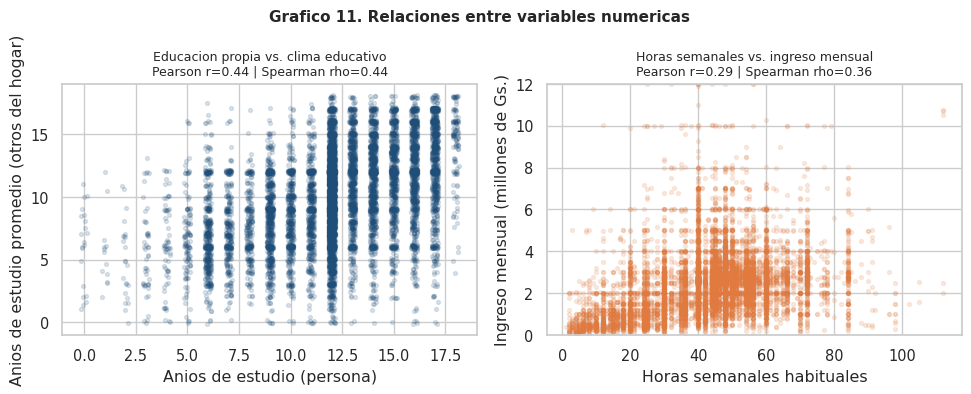

educ_anios         vs clima_educativo    Pearson r= 0.439 - Spearman rho= 0.440
ingreso            vs horas              Pearson r= 0.285 - Spearman rho= 0.362
ingreso            vs educ_anios         Pearson r= 0.238 - Spearman rho= 0.253
ingreso_hora       vs horas              Pearson r=-0.271 - Spearman rho=-0.252
edad               vs antiguedad         Pearson r= 0.302 - Spearman rho= 0.287
tam_hogar          vs otros_ocupados_n   Pearson r= 0.602 - Spearman rho= 0.559


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
dd = final[NUM].dropna()
x, y = dd["educ_anios"], dd["clima_educativo"]
jx = x + np.random.uniform(-0.15, 0.15, len(x))
jy = y + np.random.uniform(-0.15, 0.15, len(y))
r, rho = pearsonr(x, y)[0], spearmanr(x, y)[0]
axes[0].scatter(jx, jy, s=8, alpha=0.15, color=AZUL)
axes[0].set_title(f"Educacion propia vs. clima educativo\nPearson r={r:.2f} | Spearman rho={rho:.2f}", fontsize=9)
axes[0].set_xlabel("Anios de estudio (persona)")
axes[0].set_ylabel("Anios de estudio promedio (otros del hogar)")

x2, y2 = dd["horas"], dd["ingreso"] / 1e6
r2, rho2 = pearsonr(dd["horas"], dd["ingreso"])[0], spearmanr(dd["horas"], dd["ingreso"])[0]
axes[1].scatter(x2, y2, s=8, alpha=0.15, color=NARANJA)
axes[1].set_ylim(0, 12)
axes[1].set_title(f"Horas semanales vs. ingreso mensual\nPearson r={r2:.2f} | Spearman rho={rho2:.2f}", fontsize=9)
axes[1].set_xlabel("Horas semanales habituales")
axes[1].set_ylabel("Ingreso mensual (millones de Gs.)")

fig.suptitle("Grafico 11. Relaciones entre variables numericas", fontsize=11, weight="bold")
plt.tight_layout(); plt.show()
dd = final[NUM].dropna()
pares_num = [("educ_anios", "clima_educativo"), ("ingreso", "horas"), ("ingreso", "educ_anios"),
         ("ingreso_hora", "horas"), ("edad", "antiguedad"), ("tam_hogar", "otros_ocupados_n")]
for a, b in pares_num:
    print(f"{a:18s} vs {b:18s} Pearson r={pearsonr(dd[a], dd[b])[0]:6.3f} - "
          f"Spearman rho={spearmanr(dd[a], dd[b])[0]:6.3f}")

## 4.6. Bivariado: numérica frente a categórica

Se usa la **U de Mann-Whitney** en lugar de la prueba t porque la fuerte asimetría de las variables
de ingreso desaconseja comparar medias.

In [ ]:
for c in ["ingreso", "ingreso_hora", "horas", "educ_anios", "clima_educativo",
          "antiguedad", "edad", "tam_hogar"]:
    a = final[final.informal == 1][c].dropna()
    b = final[final.informal == 0][c].dropna()
    u, p = mannwhitneyu(a, b)
    dif = 100 * (a.median() - b.median()) / b.median() if b.median() else np.nan
    print(f"{c:18s} informal={a.median():12,.1f} | formal={b.median():12,.1f} "
          f"| dif={dif:6.1f} % | p={p:.1e}")

---
# Etapa 5 — Análisis descriptivo y exploratorio

Cada gráfico se acompaña de los valores que representa, impresos debajo, y de su interpretación
escrita.

In [ ]:
W = lambda x, c="informal": np.average(x[c], weights=x.factor)

g = final.groupby("periodo").apply(lambda x: W(x)).rename("tasa").to_frame()
g["mm3"] = g.tasa.rolling(3, center=True).mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(g.index, g.tasa * 100, "o-", color=AZUL, label="Tasa trimestral")
ax.plot(g.index, g.mm3 * 100, "--", color=NARANJA, lw=2, label="Media movil (3 trimestres)")
ax.set_title("Grafico 1. Informalidad en ocupados de 18 a 29 anios, 2024-2026",
             fontsize=11, weight="bold")
ax.set_xlabel("Trimestre"); ax.set_ylabel("% de informales (ponderado)"); ax.set_ylim(55, 80)
ax.legend(); plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

display((g * 100).round(1))
print(f"Minimo: {g.tasa.min()*100:.1f} % - Maximo: {g.tasa.max()*100:.1f} %")

**Interpretación.** La tasa oscila en una banda estrecha sin tendencia ni quiebre: la diferencia
entre el trimestre más alto y el más bajo es de menos de cinco puntos, del mismo orden que la
variación trimestral ordinaria. La informalidad juvenil se comporta como un fenómeno
**estructural y no coyuntural**, lo que refuerza la pertinencia de buscar determinantes estables
como los que analiza este trabajo.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3.8))
s = final[final.ingreso > 0].ingreso / 1e6
ax.hist(s, bins=60, color=AZUL, alpha=.85)
ax.axvline(s.median(), color=NARANJA, lw=2, label=f"Mediana: {s.median():.2f} M Gs.")
ax.axvline(s.mean(), color="gray", lw=2, ls="--", label=f"Media: {s.mean():.2f} M Gs.")
ax.set_xlim(0, 12)
ax.set_title("Grafico 2. Distribucion del ingreso de la ocupacion principal",
             fontsize=11, weight="bold")
ax.set_xlabel("Millones de guaranies por mes"); ax.set_ylabel("Frecuencia (casos)")
ax.legend(); plt.tight_layout(); plt.show()

print(f"Asimetria: {stats.skew(s):.2f} - Curtosis: {stats.kurtosis(s):.2f}")
print(f"Ingresos declarados en cero (excluidos del grafico): {(final.ingreso == 0).sum()}")

**Interpretación.** Distribución unimodal con una cola derecha muy prolongada. Con una asimetría
superior a 5, la media queda por encima de la mediana y deja de describir el caso típico: toda
inferencia sobre ingresos de este trabajo se basa en la mediana. El gráfico excluye los ingresos
declarados en cero, que corresponden a trabajadores familiares no remunerados.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.8))
dd_box = final[final.ingreso > 0].copy()
dd_box["cond"] = dd_box.informal.map({1: "Informal", 0: "Formal"})
sns.boxplot(data=dd_box, x="cond", y=dd_box.ingreso / 1e6, ax=ax, hue="cond",
            palette=[NARANJA, AZUL], showfliers=False, width=.5, legend=False)
ax.set_title("Grafico 3. Ingreso mensual segun condicion de formalidad",
             fontsize=11, weight="bold")
ax.set_xlabel(""); ax.set_ylabel("Millones de guaranies por mes")
plt.tight_layout(); plt.show()

med = dd_box.groupby("cond").ingreso.median()
print("Mediana de ingreso, excluyendo ingresos cero (Gs./mes):")
print(med.round(0).to_string())
print(f"Brecha en este grafico: {100*(med['Informal']-med['Formal'])/med['Formal']:.1f} %")
print("(la tabla 4.6 incluye los ingresos cero y arroja una brecha distinta)")

**Interpretación.** Las cajas se solapan parcialmente pero la diferencia de medianas es clara, y
la caja de los informales es más ancha en su mitad inferior: la precariedad no solo baja el
ingreso sino que lo vuelve más disperso hacia abajo. El ingreso, sin embargo, **no se usa como
predictor** en este trabajo: es una consecuencia de la informalidad, no una causa.

In [ ]:
TRAMOS = {1: "Solo", 2: "2 a 5", 3: "6 a 10", 4: "11 a 20", 5: "21 a 30",
          6: "31 a 50", 7: "51 a 100", 8: "101 a 500", 9: "Mas de 500"}
t = final[final.tam_empresa.isin(TRAMOS)]
vals = [W(t[t.tam_empresa == x]) * 100 for x in TRAMOS]
enes = [len(t[t.tam_empresa == x]) for x in TRAMOS]

fig, ax = plt.subplots(figsize=(9, 4))
b = ax.bar(range(len(TRAMOS)), vals, color=sns.color_palette("Oranges_r", len(TRAMOS)))
ax.bar_label(b, fmt="%.1f %%", fontsize=8)
ax.set_xticks(range(len(TRAMOS))); ax.set_xticklabels(list(TRAMOS.values()), fontsize=9)
ax.set_ylim(0, 105); ax.set_ylabel("% de informales (ponderado)")
ax.set_xlabel("Personas que trabajan en el establecimiento")
ax.set_title("Grafico 4. Informalidad segun tamano del establecimiento",
             fontsize=11, weight="bold")
plt.tight_layout(); plt.show()

for e, v, n in zip(TRAMOS.values(), vals, enes):
    print(f"  {e:12s} {v:5.1f} %   (n = {n})")
print(f"Amplitud: {max(vals) - min(vals):.1f} puntos porcentuales")

**Interpretación.** La variable más asociada de todo el conjunto, y la relación es **fuerte pero
no monótona**: el máximo no está en quienes trabajan solos sino en las microempresas de 2 a 5
personas. A partir de ahí el descenso es sostenido y muy pronunciado hasta los establecimientos
más grandes, con una amplitud superior a los 65 puntos porcentuales.

Que el cuentapropismo tenga menos informalidad que la microempresa sugiere que entre quienes
trabajan solos convive un grupo de independientes formalizados con el grueso del trabajo
precario.

In [ ]:
orden = ["Primaria incompleta (0-5)", "EEB (6-9)", "Media (10-12)", "Superior (13+)"]
vals_e = [W(final[final.educ_nivel == x]) * 100 for x in orden]
vals_c = [W(final[final.clima_educ_nivel == x]) * 100 for x in orden]

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(4); ancho = 0.38
b1 = ax.bar(x - ancho/2, vals_e, ancho, label="Educacion propia", color=AZUL)
b2 = ax.bar(x + ancho/2, vals_c, ancho, label="Clima educativo del hogar", color=NARANJA)
ax.bar_label(b1, fmt="%.1f", fontsize=8); ax.bar_label(b2, fmt="%.1f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(["Primaria\nincompleta", "EEB\n(6-9)",
                                      "Media\n(10-12)", "Superior\n(13+)"], fontsize=9)
ax.set_ylim(0, 105); ax.set_ylabel("% de informales (ponderado)")
ax.set_title("Grafico 5. Educacion propia y del hogar frente a la informalidad",
             fontsize=11, weight="bold")
ax.legend(); plt.tight_layout(); plt.show()

for n, a, c in zip(orden, vals_e, vals_c):
    print(f"  {n:28s} propia {a:5.1f} %   hogar {c:5.1f} %")
print(f"Amplitud educacion propia : {vals_e[0] - vals_e[-1]:.1f} puntos")
print(f"Amplitud clima del hogar  : {vals_c[0] - vals_c[-1]:.1f} puntos")

**Interpretación.** Ambos gradientes son monótonos y descendentes, pero el de la **educación
propia es más pronunciado** que el del clima educativo del hogar. La educación de la persona
discrimina más que la de su entorno, aunque la diferencia no es enorme y las dos variables están
correlacionadas entre sí, lo que anticipa que parte del efecto se solapará en la regresión de la
Fase 2.

In [ ]:
orden_e = ["Ninguno", "Minoria", "Mayoria", "Todos", "Sin otros ocupados"]
vals = [W(final[final.entorno_informal == x]) * 100 for x in orden_e]
enes = [len(final[final.entorno_informal == x]) for x in orden_e]

fig, ax = plt.subplots(figsize=(8.5, 3.8))
colores = [AZUL] * 4 + ["gray"]
b = ax.bar(range(5), vals, color=colores)
ax.bar_label(b, fmt="%.1f %%", fontsize=9)
ax.set_xticks(range(5))
ax.set_xticklabels(["Ninguno", "Minoria", "Mayoria", "Todos", "Sin otros\nocupados"], fontsize=9)
ax.set_ylim(0, 100); ax.set_ylabel("% de informales (ponderado)")
ax.set_xlabel("Proporcion de informales entre los OTROS ocupados del hogar")
ax.set_title("Grafico 6. Entorno de informalidad del hogar", fontsize=11, weight="bold")
plt.tight_layout(); plt.show()

for n, v, e in zip(orden_e, vals, enes):
    print(f"  {n:20s} {v:5.1f} %   (n = {e})")
print(f"Amplitud entre 'Ninguno' y 'Todos': {vals[3] - vals[0]:.1f} puntos porcentuales")

**Interpretación.** El gradiente es claro y ordenado: la informalidad de la persona aumenta de
forma sostenida con la proporción de informales entre los demás ocupados de su hogar, con una
amplitud de casi 30 puntos entre los extremos.

La quinta barra, en gris, corresponde a quienes son el **único ocupado de su hogar**. No es un
valor faltante sino una situación distinta, y por eso se conserva como categoría explícita en
lugar de imputarse o eliminarse.

Conviene subrayar la limitación: esto mide **asociación, no transmisión**. Los miembros de un
hogar comparten barrio, nivel socioeconómico, redes de contacto y acceso educativo, de modo que la
coincidencia puede deberse a cualquiera de esos factores comunes.

In [ ]:
OCUPACIONES = {1: "Directivos", 2: "Profesionales", 3: "Tecnicos", 4: "Oficinistas",
               5: "Servicios y ventas", 7: "Operarios y artesanos",
               8: "Operadores de maquinas", 9: "No calificados"}
o = final[final.ocupacion.isin(OCUPACIONES)]
vals = [W(o[o.ocupacion == k]) * 100 for k in OCUPACIONES]
enes = [len(o[o.ocupacion == k]) for k in OCUPACIONES]
orden_idx = np.argsort(vals)

fig, ax = plt.subplots(figsize=(8.5, 4))
etiquetas = [list(OCUPACIONES.values())[i] for i in orden_idx]
ax.barh(etiquetas, [vals[i] for i in orden_idx], color=AZUL)
for i, v in enumerate([vals[i] for i in orden_idx]):
    ax.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=8)
ax.set_xlim(0, 100); ax.set_xlabel("% de informales (ponderado)")
ax.set_title("Grafico 7. Informalidad segun ocupacion desempenada",
             fontsize=11, weight="bold")
plt.tight_layout(); plt.show()

for k, v, e in zip(OCUPACIONES.values(), vals, enes):
    print(f"  {k:24s} {v:5.1f} %   (n = {e})")

**Interpretación.** El gradiente ocupacional es muy amplio y ordena con nitidez el mercado laboral
juvenil: las ocupaciones que requieren calificación formal presentan tasas muy inferiores a las de
servicios, operarios y trabajo no calificado. Se excluyen del gráfico las categorías con muy pocos
casos, cuyos porcentajes serían ruido.

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
etiq = ["Edad", "Educ. propia", "Clima educ.", "Tam. hogar", "Otros ocupados",
        "Antiguedad", "Horas", "Ingreso", "Ing./hora"]
m = final[NUM].corr(method="spearman")
m.index = m.columns = etiq
sns.heatmap(m, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            annot_kws={"size": 8}, cbar_kws={"label": "rho de Spearman"})
ax.set_title("Grafico 8. Matriz de correlaciones (Spearman)", fontsize=11, weight="bold")
plt.tight_layout(); plt.show()

pares_corr = [(a, b, abs(m.loc[a, b])) for a, b in itertools.combinations(etiq, 2)]
print("Correlaciones mas altas:")
for a, b, v in sorted(pares_corr, key=lambda x: -x[2])[:5]:
    print(f"  {a:16s} {b:16s} {v:.3f}")

**Interpretación.** No se observan correlaciones extremas entre los predictores, de modo que no se
anticipan problemas graves de multicolinealidad en la regresión de la Fase 2. Los pares más altos
corresponden a variables emparentadas por construcción —ingreso e ingreso por hora, tamaño del
hogar y cantidad de ocupados— que no se usarán simultáneamente como predictores.

La correlación entre la educación propia y el clima educativo del hogar es moderada: suficiente
para anticipar solapamiento en el modelo, pero lejos de indicar que midan lo mismo.

In [ ]:
dp = final.groupby("departamento").apply(
    lambda x: pd.Series({"tasa": W(x) * 100, "n": len(x)}))
dp = dp[dp.n >= 150].sort_values("tasa")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(dp.index, dp.tasa, color=AZUL)
for i, t_ in enumerate(dp.tasa):
    ax.text(t_ + 1, i, f"{t_:.0f}%", va="center", fontsize=8)
ax.set_xlim(0, 100); ax.set_xlabel("% de informales (ponderado)")
ax.set_title("Grafico 9. Informalidad por departamento (n >= 150)",
             fontsize=11, weight="bold")
plt.tight_layout(); plt.show()

display(dp.round(1))
print(f"Amplitud entre extremos: {dp.tasa.max() - dp.tasa.min():.1f} puntos porcentuales")

**Interpretación.** La dispersión territorial es amplia. Asunción y Central presentan las tasas
más bajas, coherente con la concentración de empleo formal en el área metropolitana. Se excluyen
los departamentos con menos de 150 casos porque el diseño muestral de la EPHC garantiza inferencia
a nivel nacional y urbano-rural, no departamental.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, (var, nombre, orden_v) in zip(axes, [
        ("edad_grupo", "Grupo de edad", ["18-21", "22-25", "26-29"]),
        ("rural", "Area de residencia", [0, 1])]):
    vals = [W(final[final[var] == x]) * 100 for x in orden_v]
    etiquetas = orden_v if var == "edad_grupo" else ["Urbano", "Rural"]
    b = ax.bar(range(len(vals)), vals, color=AZUL, width=.55)
    ax.bar_label(b, fmt="%.1f %%", fontsize=9)
    ax.set_xticks(range(len(vals))); ax.set_xticklabels(etiquetas)
    ax.set_ylim(0, 100); ax.set_ylabel("% de informales"); ax.set_title(nombre, fontsize=10)
    for e, v in zip(etiquetas, vals):
        print(f"  {nombre:20s} {str(e):10s} {v:5.1f} %")
fig.suptitle("Grafico 10. Edad y territorio frente a la informalidad",
             fontsize=11, weight="bold")
plt.tight_layout(); plt.show()

**Interpretación.** La informalidad desciende con la edad dentro de la franja juvenil, lo que es
coherente con trayectorias de inserción que comienzan en empleos precarios. La brecha entre el
grupo más joven y el mayor supera los quince puntos. La diferencia entre área rural y urbana
también es marcada, aunque menor en magnitud que la educativa o la del puesto de trabajo.

## 5.1. Patrones y anomalías identificados

In [ ]:
# El orden de las dimensiones ya quedo establecido en la tabla de 4.4.
# Aqui solo se agrega lo que esa tabla no mostraba de forma directa.
print("Variables con asociacion practicamente nula (V < 0,05):")
print(ranking[ranking["V de Cramer"] < 0.05][["Variable", "V de Cramer", "Valor p"]]
      .to_string(index=False))
print()
print(f"Dimension mas asociada : {resumen_dim.index[0]} (V = {resumen_dim.iloc[0]:.3f})")
print(f"Dimension menos asociada: {resumen_dim.index[-1]} (V = {resumen_dim.iloc[-1]:.3f})")

**Patrón 1 — La estructura del puesto domina sobre todo lo demás.** El tamaño del establecimiento
es, con amplio margen, la variable más asociada a la informalidad, y la dimensión del puesto reúne
además la ocupación y la rama. *Implicación:* cualquier modelo que omita estas variables atribuirá
erróneamente a la persona un efecto que corresponde al tipo de empleo al que accede.

**Patrón 2 — El hogar importa, pero solo si se lo mide bien.** Las dos variables construidas por
agregación sobre los miembros del hogar alcanzan una asociación comparable a la de la educación
individual, mientras que las variables simples del hogar —tamaño, ser jefe/a— son prácticamente
irrelevantes. *Implicación:* el contexto del hogar es una dimensión real, pero requiere
construcción cuidadosa para hacerse visible.

**Patrón 3 — La informalidad juvenil es estructural.** Diez trimestres sin tendencia ni quiebre,
con una banda de variación inferior a cinco puntos.

**Anomalía 1 — El sexo y el estado civil no se asocian con la informalidad.** Ambos arrojan V de
Cramér por debajo de 0,05, pese a valores p significativos. Es el ejemplo perfecto de la distinción
entre significancia estadística y relevancia práctica que la Fase 2 exige discutir: con más de doce
mil casos, diferencias triviales resultan significativas.

**Anomalía 2 — La relación con el tamaño del establecimiento no es monótona.** Quienes trabajan
solos presentan menos informalidad que las microempresas de 2 a 5 personas, contra lo que sugeriría
una lectura lineal.

## 5.2. Hipótesis para la Fase 2

| N.º | Hipótesis | Prueba prevista |
|---|---|---|
| H1 | La proporción de informales difiere según el tamaño del establecimiento. | Chi-cuadrado con V de Cramér |
| H2 | La educación propia mantiene asociación con la informalidad al controlar el puesto de trabajo, el territorio y el hogar. | Regresión logística múltiple |
| H3 | El entorno de informalidad del hogar aporta capacidad explicativa adicional una vez controlados los factores individuales y del puesto. | Comparación de modelos anidados |
| H4 | El ingreso mediano de los informales es menor que el de los formales, incluso medido por hora trabajada. | U de Mann-Whitney con tamaño del efecto |
| H5 | El sexo no se asocia con la informalidad una vez controlados los demás factores. | Regresión logística; intervalo por bootstrap |

Las cinco cubren tres familias distintas de pruebas, incorporan tamaño del efecto y contemplan un
intervalo estimado por bootstrap. **Todas admiten resultado negativo**, incluida H5, que está
formulada de modo que confirmar la ausencia de efecto sea un resultado válido.

## Limitaciones detectadas

**Asociación, no causalidad.** Con datos transversales no puede afirmarse que ninguno de estos
factores *cause* la informalidad. En particular, la dirección entre ocupación y formalidad puede
correr en ambos sentidos.

**Dependencia entre observaciones dentro del hogar.** Varios casos del conjunto pertenecen al mismo
hogar y comparten por construcción el clima educativo y el entorno de informalidad. La corrección
adecuada son errores estándar agrupados por hogar, técnica que corresponde a la Fase 2.

In [ ]:
print(f"Casos                             : {len(final):,}")
print(f"Hogares distintos                 : {final.ID_HOGAR.nunique():,}")
print(f"Casos que comparten hogar con otro: {len(final) - final.ID_HOGAR.nunique():,}")
print()
print(f"Archivos generados en {SALIDA}:")
print("  dataset_limpio.csv - bitacora_limpieza.csv")

Casos                             : 12,691
Hogares distintos                 : 10,055
Casos que comparten hogar con otro: 2,636

Archivos generados en /content/drive/MyDrive/datos_limpios:
  dataset_limpio.csv - bitacora_limpieza.csv


In [ ]:
from google.colab import files
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/Fase1_Informalidad_Juvenil.ipynb"
files.download("/content/drive/MyDrive/Colab Notebooks/Fase1_Informalidad_Juvenil.html")

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Fase1_Informalidad_Juvenil.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 918265 bytes to /content/drive/MyDrive/Colab Notebooks/Fase1_Informalidad_Juvenil.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>